# Exploratory Data Analysis

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tsa.seasonal import STL

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-01-01')
COVID_END = pd.Timestamp('2021-12-31')

sns.set_palette('colorblind')

## Data Import

In [2]:
df = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, 'train.parquet'))

df = df.set_index('date')
df['is_covid_19'] = (df.index >= COVID_START) & (df.index <= COVID_END)

df.head()

,access_route,state,origin_country,month,year,arrival_count,month_num,year_month,state_region,country_cultural_subdivision,is_covid_19
date,,,,,,,,,,,
1989-01-31,Aérea,Amazonas,África do Sul,Janeiro,1989,9.0,01,1989-01-31,Região Norte,Sub-Saharan Africa,False
1989-01-31,Aérea,Amazonas,Angola,Janeiro,1989,0.0,01,1989-01-31,Região Norte,Sub-Saharan Africa,False
1989-01-31,Aérea,Amazonas,Nigéria,Janeiro,1989,0.0,01,1989-01-31,Região Norte,Sub-Saharan Africa,False
1989-01-31,Aérea,Amazonas,Outros países,Janeiro,1989,0.0,01,1989-01-31,Região Norte,Outros,False
1989-01-31,Aérea,Amazonas,Costa Rica,Janeiro,1989,6.0,01,1989-01-31,Região Norte,LATAM,False


## Categorical Features Analysis

### Access Route

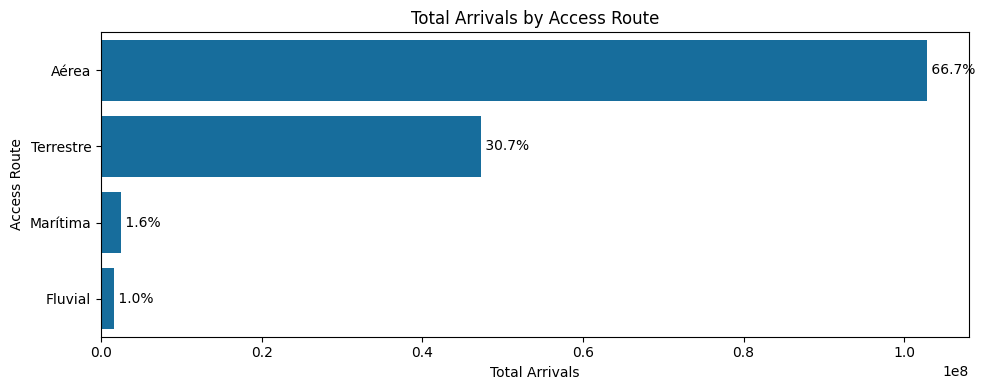

In [3]:
top_access_route = pd.DataFrame(
    df.groupby('access_route')['arrival_count'].sum().nlargest(20)
)
top_access_route['percentage'] = (
    top_access_route['arrival_count'] / top_access_route['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 4))

sns.barplot(x=top_access_route['arrival_count'], y=top_access_route.index)
plt.title('Total Arrivals by Access Route')
plt.xlabel('Total Arrivals')
plt.ylabel('Access Route')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_access_route['arrival_count'], top_access_route['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

plt.tight_layout()

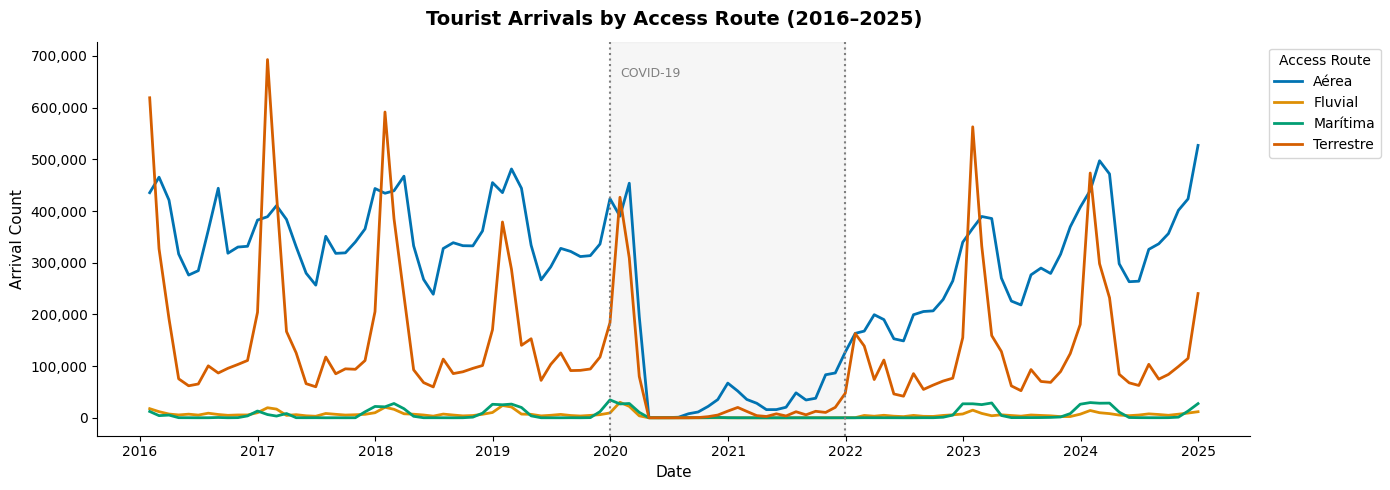

In [4]:
route_time = (
    df[df.index.year >= 2016]
    .groupby(['year_month', 'access_route'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=route_time,
    x='year_month',
    y='arrival_count',
    hue='access_route',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = route_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    'Tourist Arrivals by Access Route (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Arrival Count', fontsize=11)
ax.legend(
    title='Access Route', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

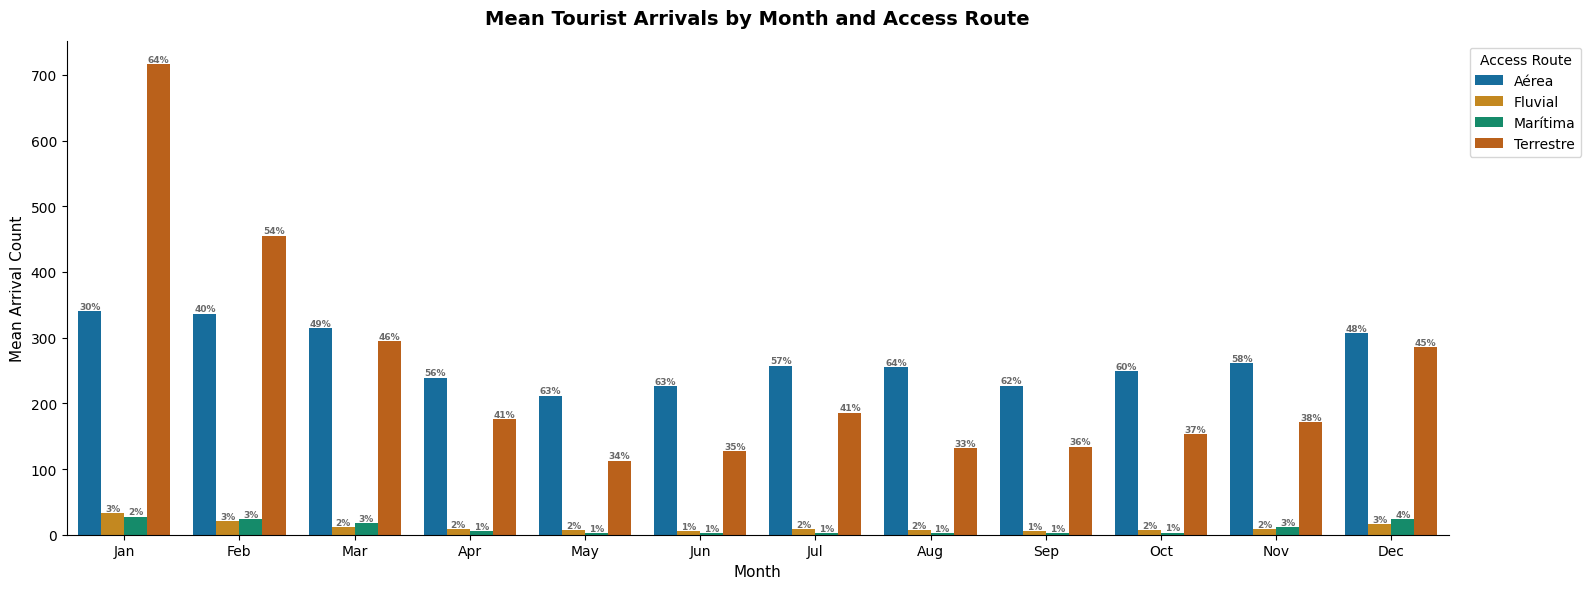

In [5]:
month_route = (
    df.groupby(['month_num', 'access_route'])['arrival_count'].mean().reset_index()
)

month_totals = month_route.groupby('month_num')['arrival_count'].sum()
month_route['pct'] = month_route.apply(
    lambda r: r['arrival_count'] / month_totals[r['month_num']] * 100, axis=1
)

month_labels = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]
month_route['month_label'] = (
    month_route['month_num'].astype(int).apply(lambda m: month_labels[m - 1])
)

fig, ax = plt.subplots(figsize=(16, 6))

sns.barplot(
    data=month_route,
    x='month_label',
    y='arrival_count',
    hue='access_route',
    order=month_labels,
    ax=ax,
)

for bar in ax.patches:
    height = bar.get_height()
    if height > 0:
        x = bar.get_x() + bar.get_width() / 2
        ax.text(
            x,
            height + 0.5,
            f'{height / month_route["arrival_count"].max() * 100:.0f}%',
            ha='center',
            va='bottom',
            fontsize=6.5,
            color='dimgray',
        )

# re-annotate with actual pct values per bar group
ax.cla()
bar_plot = sns.barplot(
    data=month_route,
    x='month_label',
    y='arrival_count',
    hue='access_route',
    order=month_labels,
    ax=ax,
)

routes = month_route['access_route'].unique()
for month_idx, month in enumerate(month_labels):
    month_data = month_route[month_route['month_label'] == month].set_index(
        'access_route'
    )
    n_routes = len(routes)
    total_width = 0.8
    bar_width = total_width / n_routes
    for route_idx, route in enumerate(routes):
        if route not in month_data.index:
            continue
        row = month_data.loc[route]
        x = month_idx - total_width / 2 + bar_width * route_idx + bar_width / 2
        ax.text(
            x,
            row['arrival_count'] + 0.3,
            f'{row["pct"]:.0f}%',
            ha='center',
            va='bottom',
            fontsize=6.5,
            color='dimgray',
            fontweight='bold',
        )

ax.set_title(
    'Mean Tourist Arrivals by Month and Access Route',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Mean Arrival Count', fontsize=11)
ax.legend(
    title='Access Route', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

### Arrival State and Region

#### Arrival State

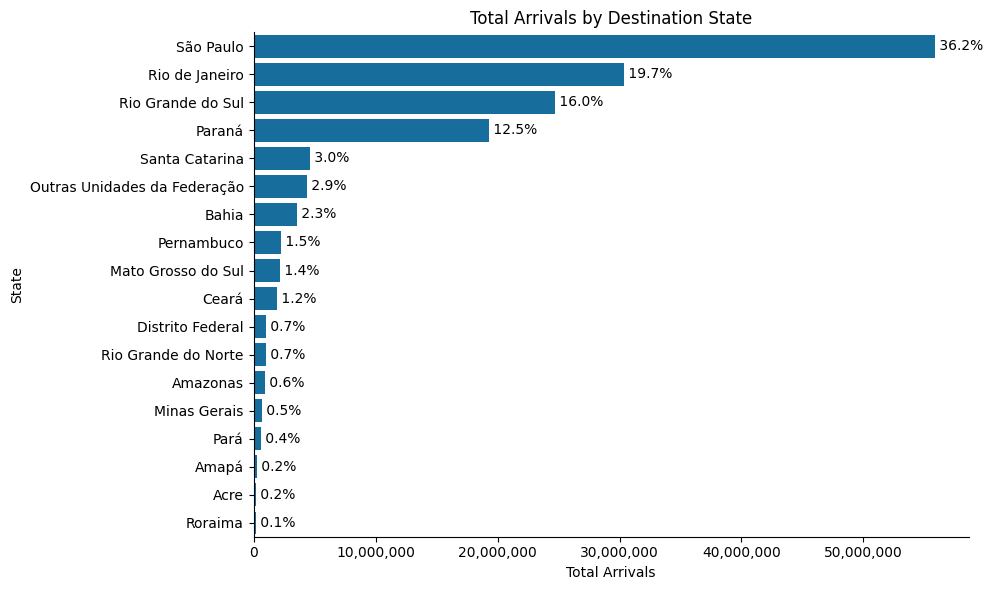

In [6]:
top_states = pd.DataFrame(df.groupby('state')['arrival_count'].sum().nlargest(30))
top_states['percentage'] = (
    top_states['arrival_count'] / top_states['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 6))

sns.barplot(x=top_states['arrival_count'], y=top_states.index)
plt.title('Total Arrivals by Destination State')
plt.xlabel('Total Arrivals')
plt.ylabel('State')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_states['arrival_count'], top_states['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

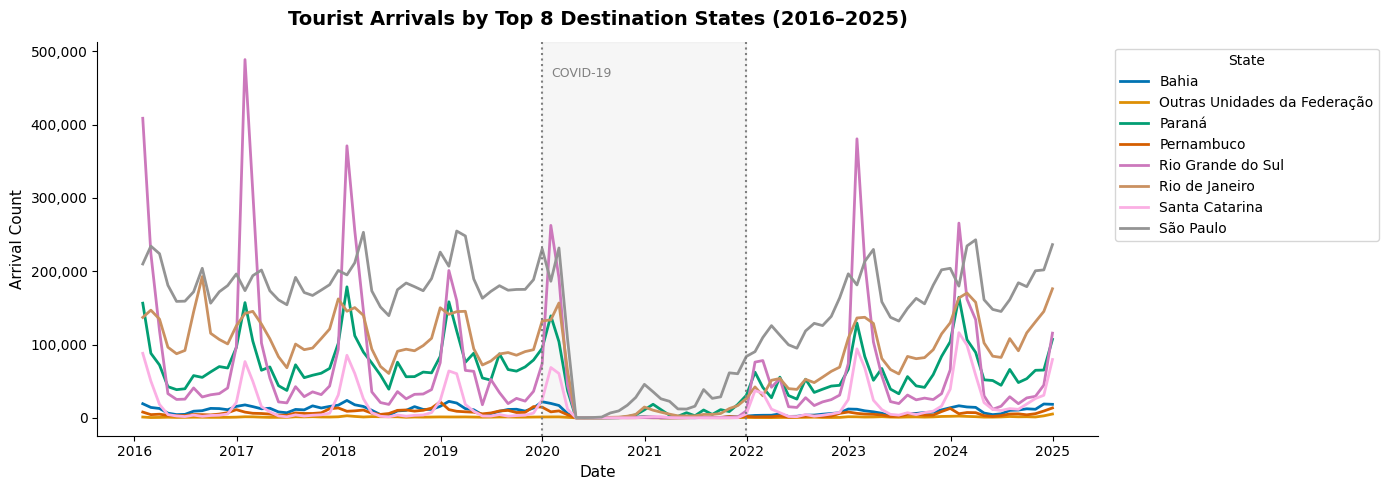

In [7]:
TOP_N = 8
top_state_names = (
    df.groupby('state')['arrival_count'].sum().nlargest(TOP_N).index.tolist()
)

state_time = (
    df[df['state'].isin(top_state_names) & (df.index.year >= 2016)]
    .groupby(['year_month', 'state'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=state_time,
    x='year_month',
    y='arrival_count',
    hue='state',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = state_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    f'Tourist Arrivals by Top {TOP_N} Destination States (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Arrival Count', fontsize=11)
ax.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

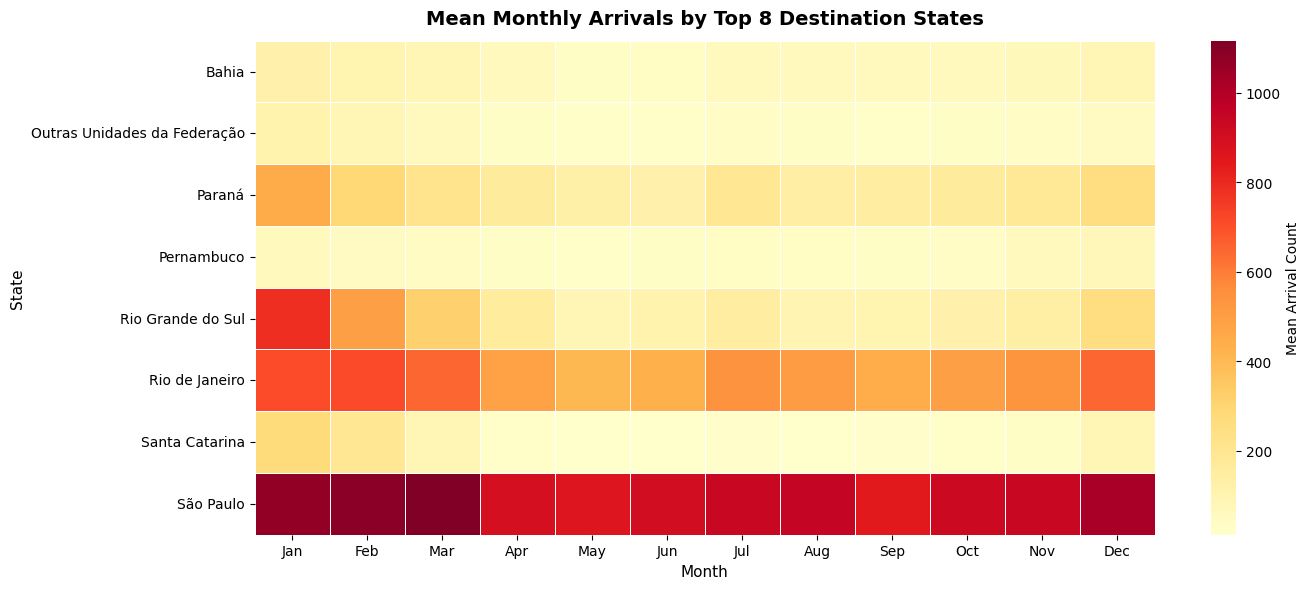

In [8]:
month_labels = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]

state_month = (
    df[df['state'].isin(top_state_names)]
    .groupby(['state', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
state_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 6))

sns.heatmap(
    state_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Mean Arrival Count'},
)

ax.set_title(
    f'Mean Monthly Arrivals by Top {TOP_N} Destination States',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('State', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

#### Arrival Region

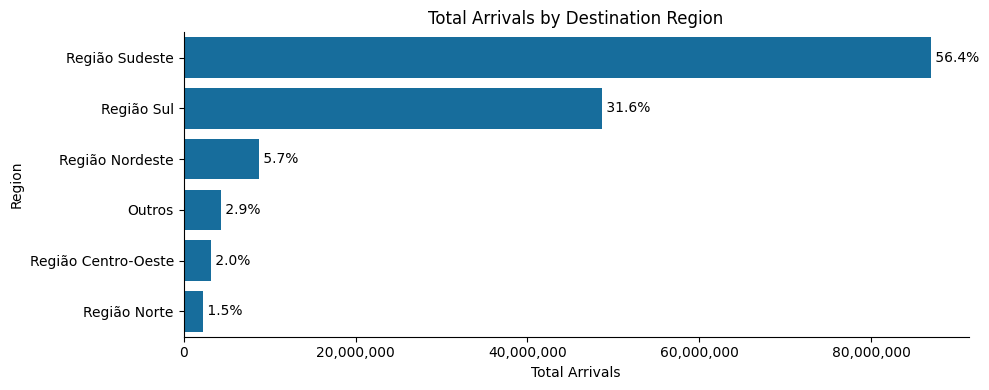

In [9]:
region_totals = pd.DataFrame(
    df.groupby('state_region')['arrival_count'].sum().sort_values(ascending=False)
)
region_totals['percentage'] = (
    region_totals['arrival_count'] / region_totals['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 4))

sns.barplot(x=region_totals['arrival_count'], y=region_totals.index)
plt.title('Total Arrivals by Destination Region')
plt.xlabel('Total Arrivals')
plt.ylabel('Region')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(region_totals['arrival_count'], region_totals['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

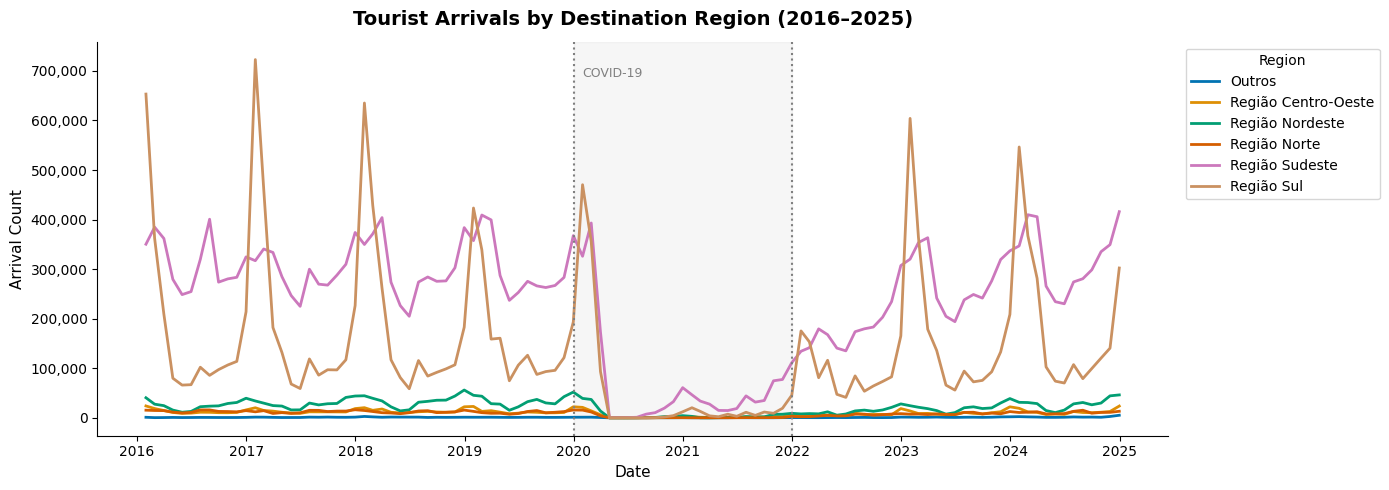

In [10]:
region_time = (
    df[df.index.year >= 2016]
    .groupby(['year_month', 'state_region'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=region_time,
    x='year_month',
    y='arrival_count',
    hue='state_region',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = region_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    'Tourist Arrivals by Destination Region (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Arrival Count', fontsize=11)
ax.legend(title='Region', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

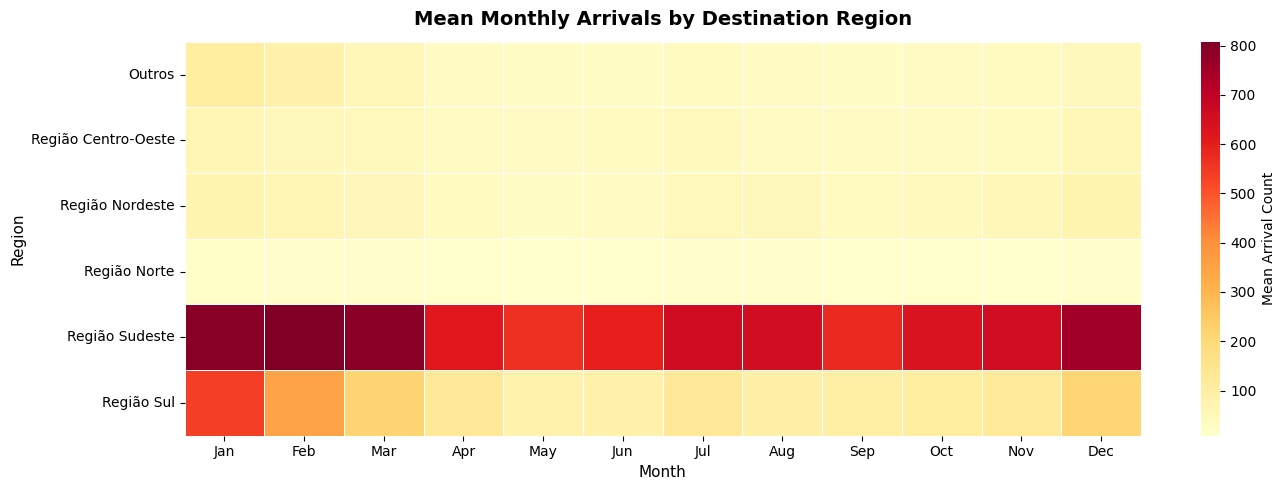

In [11]:
month_labels = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]

region_month = (
    df
    .groupby(['state_region', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
region_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    region_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Mean Arrival Count'},
)

ax.set_title(
    'Mean Monthly Arrivals by Destination Region',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Region', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

### Arrival Country / Cultural Subdivision

#### Origin Country

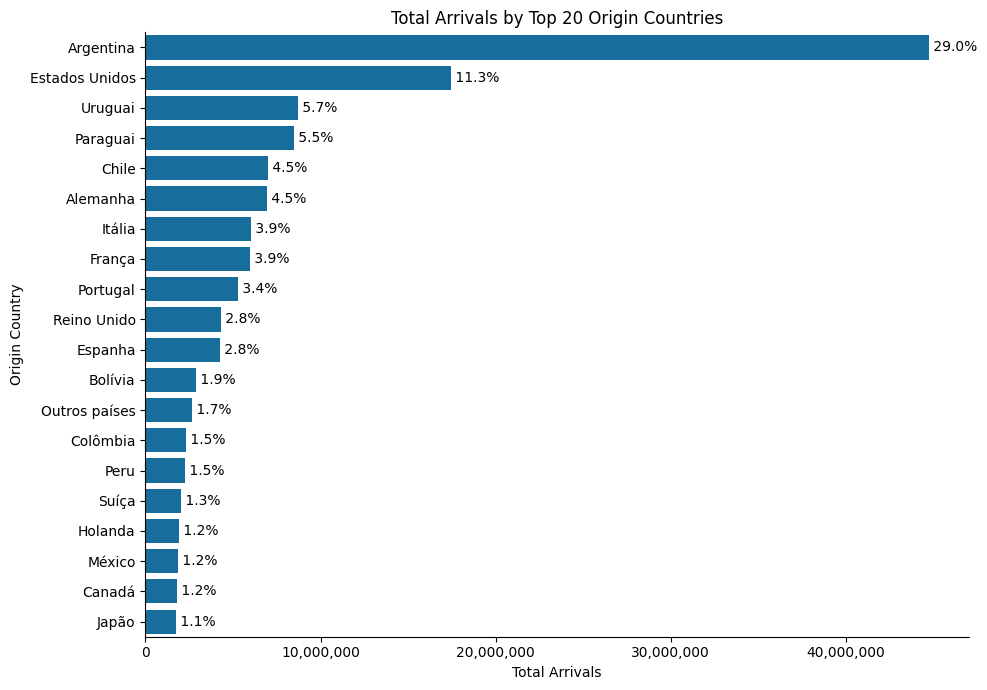

In [12]:
TOP_N_COUNTRIES = 20

top_countries = pd.DataFrame(
    df.groupby('origin_country')['arrival_count'].sum().nlargest(TOP_N_COUNTRIES)
)
top_countries['percentage'] = (
    top_countries['arrival_count']
    / df.groupby('origin_country')['arrival_count'].sum().sum()
) * 100

plt.figure(figsize=(10, 7))

sns.barplot(x=top_countries['arrival_count'], y=top_countries.index)
plt.title(f'Total Arrivals by Top {TOP_N_COUNTRIES} Origin Countries')
plt.xlabel('Total Arrivals')
plt.ylabel('Origin Country')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(top_countries['arrival_count'], top_countries['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

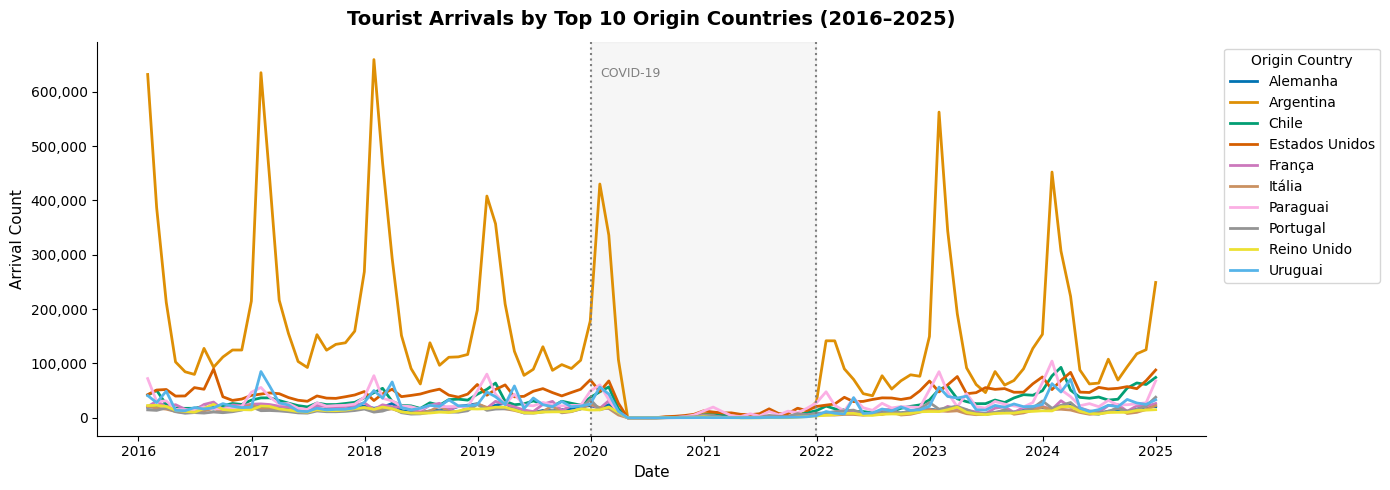

In [13]:
TOP_N_COUNTRIES = 10

top_country_names = (
    df
    .groupby('origin_country')['arrival_count']
    .sum()
    .nlargest(TOP_N_COUNTRIES)
    .index.tolist()
)

country_time = (
    df[df['origin_country'].isin(top_country_names) & (df.index.year >= 2016)]
    .groupby(['year_month', 'origin_country'], as_index=False)['arrival_count']
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=country_time,
    x='year_month',
    y='arrival_count',
    hue='origin_country',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = country_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    f'Tourist Arrivals by Top {TOP_N_COUNTRIES} Origin Countries (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Arrival Count', fontsize=11)
ax.legend(
    title='Origin Country', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=True
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

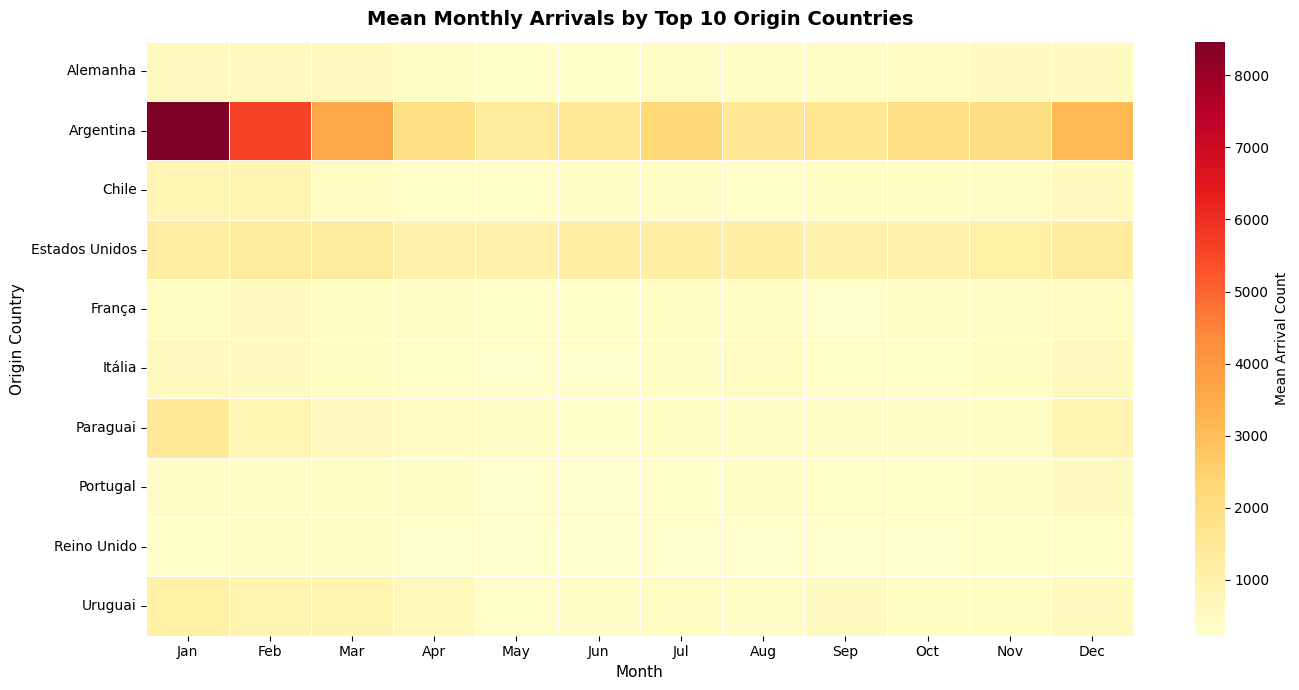

In [14]:
month_labels = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]

country_month = (
    df[df['origin_country'].isin(top_country_names)]
    .groupby(['origin_country', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
country_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    country_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Mean Arrival Count'},
)

ax.set_title(
    f'Mean Monthly Arrivals by Top {TOP_N_COUNTRIES} Origin Countries',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Origin Country', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

#### Cultural Subdivision

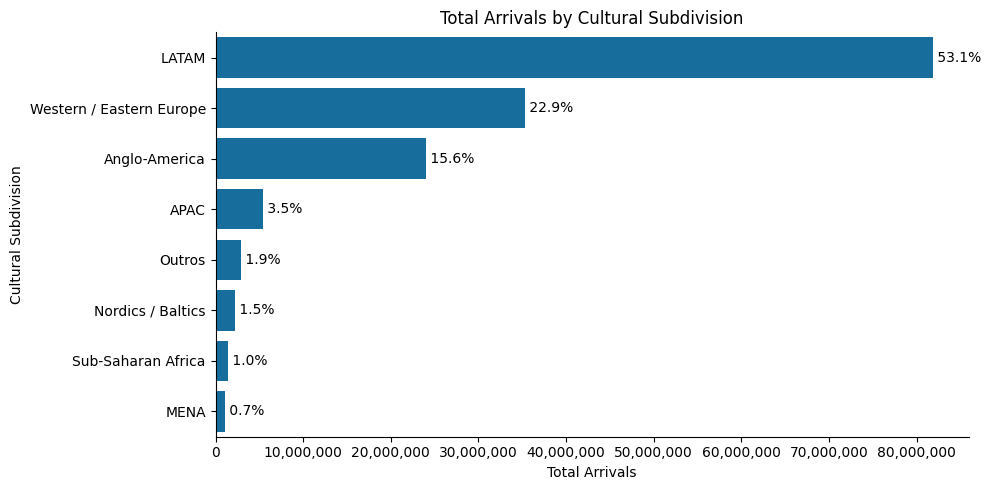

In [15]:
subdivision_totals = pd.DataFrame(
    df
    .groupby('country_cultural_subdivision')['arrival_count']
    .sum()
    .sort_values(ascending=False)
)
subdivision_totals['percentage'] = (
    subdivision_totals['arrival_count'] / subdivision_totals['arrival_count'].sum()
) * 100

plt.figure(figsize=(10, 5))

sns.barplot(x=subdivision_totals['arrival_count'], y=subdivision_totals.index)
plt.title('Total Arrivals by Cultural Subdivision')
plt.xlabel('Total Arrivals')
plt.ylabel('Cultural Subdivision')

ax = plt.gca()
for i, (count, pct) in enumerate(
    zip(subdivision_totals['arrival_count'], subdivision_totals['percentage'])
):
    ax.text(count, i, f' {pct:.1f}%', va='center', ha='left')

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

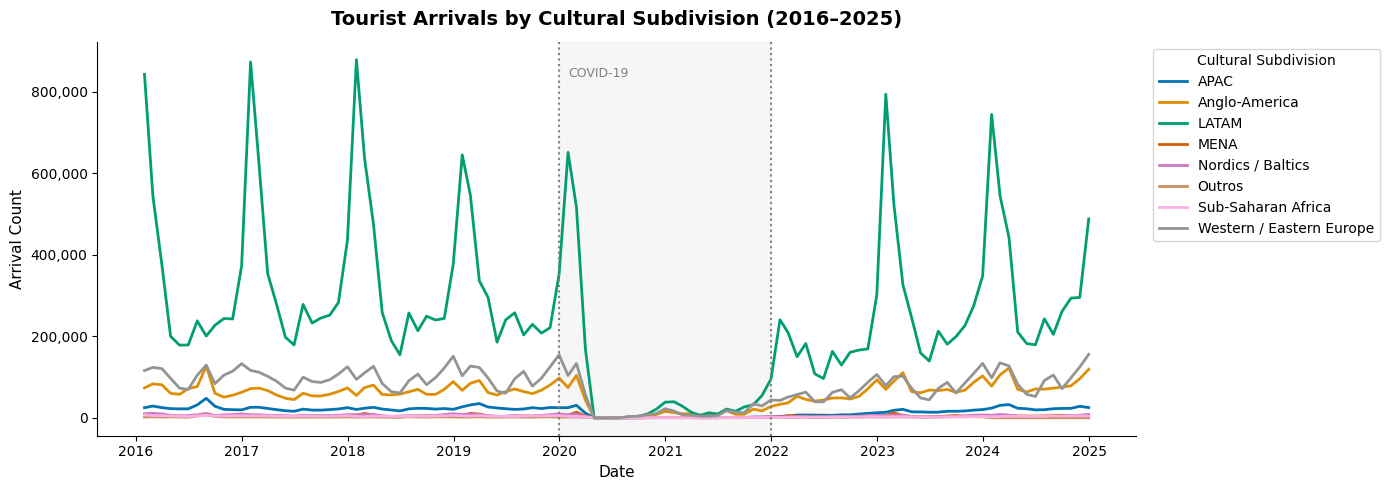

In [16]:
subdivision_time = (
    df[df.index.year >= 2016]
    .groupby(['year_month', 'country_cultural_subdivision'], as_index=False)[
        'arrival_count'
    ]
    .sum()
)

fig, ax = plt.subplots(figsize=(14, 5))

sns.lineplot(
    data=subdivision_time,
    x='year_month',
    y='arrival_count',
    hue='country_cultural_subdivision',
    linewidth=2,
    ax=ax,
)

ax.axvline(COVID_START, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvline(COVID_END, color='gray', linestyle=':', linewidth=1.5, label='_nolegend_')
ax.axvspan(COVID_START, COVID_END, alpha=0.07, color='gray')

y_max = subdivision_time['arrival_count'].max()
ax.text(
    COVID_START + pd.Timedelta(days=30),
    y_max * 0.95,
    'COVID-19',
    fontsize=9,
    color='gray',
)

ax.set_title(
    'Tourist Arrivals by Cultural Subdivision (2016–2025)',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Date', fontsize=11)
ax.set_ylabel('Arrival Count', fontsize=11)
ax.legend(
    title='Cultural Subdivision',
    bbox_to_anchor=(1.01, 1),
    loc='upper left',
    frameon=True,
)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine()
plt.tight_layout()

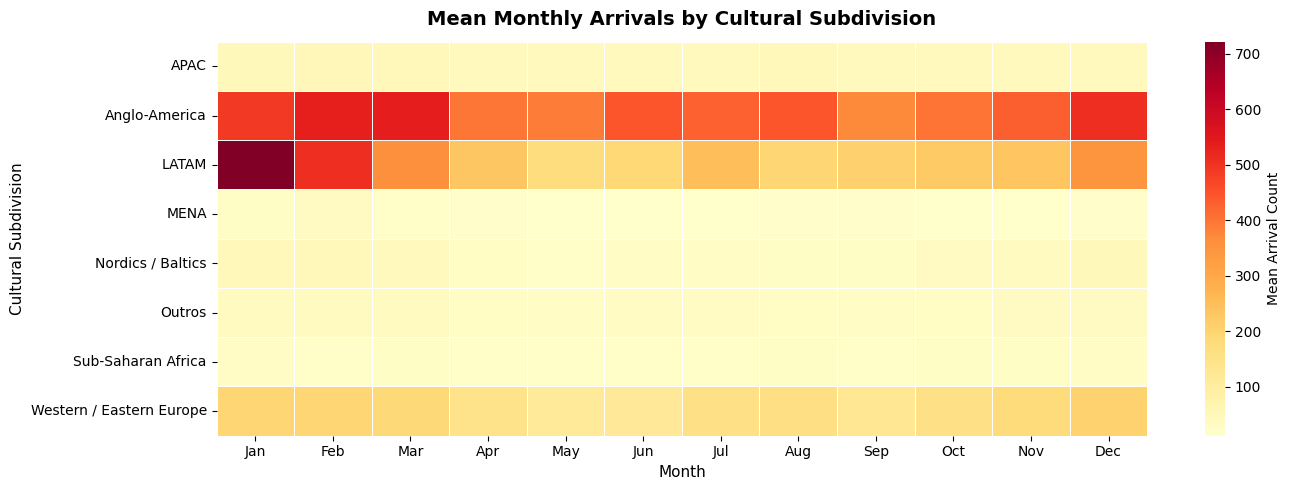

In [17]:
month_labels = [
    'Jan',
    'Feb',
    'Mar',
    'Apr',
    'May',
    'Jun',
    'Jul',
    'Aug',
    'Sep',
    'Oct',
    'Nov',
    'Dec',
]

subdivision_month = (
    df
    .groupby(['country_cultural_subdivision', 'month_num'])['arrival_count']
    .mean()
    .unstack('month_num')
)
subdivision_month.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(
    subdivision_month,
    fmt='.0f',
    linewidths=0.4,
    cmap='YlOrRd',
    ax=ax,
    cbar_kws={'label': 'Mean Arrival Count'},
)

ax.set_title(
    'Mean Monthly Arrivals by Cultural Subdivision',
    fontsize=14,
    fontweight='bold',
    pad=12,
)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Cultural Subdivision', fontsize=11)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()

## Time Series Analysis

In [18]:
monthly_df = df[['arrival_count']].resample('ME').sum()
monthly_df.head()

,arrival_count
date,
1989-01-31,291566.0
1989-02-28,197348.0
1989-03-31,149001.0
1989-04-30,84867.0
1989-05-31,69293.0


### Seasonal Decompose

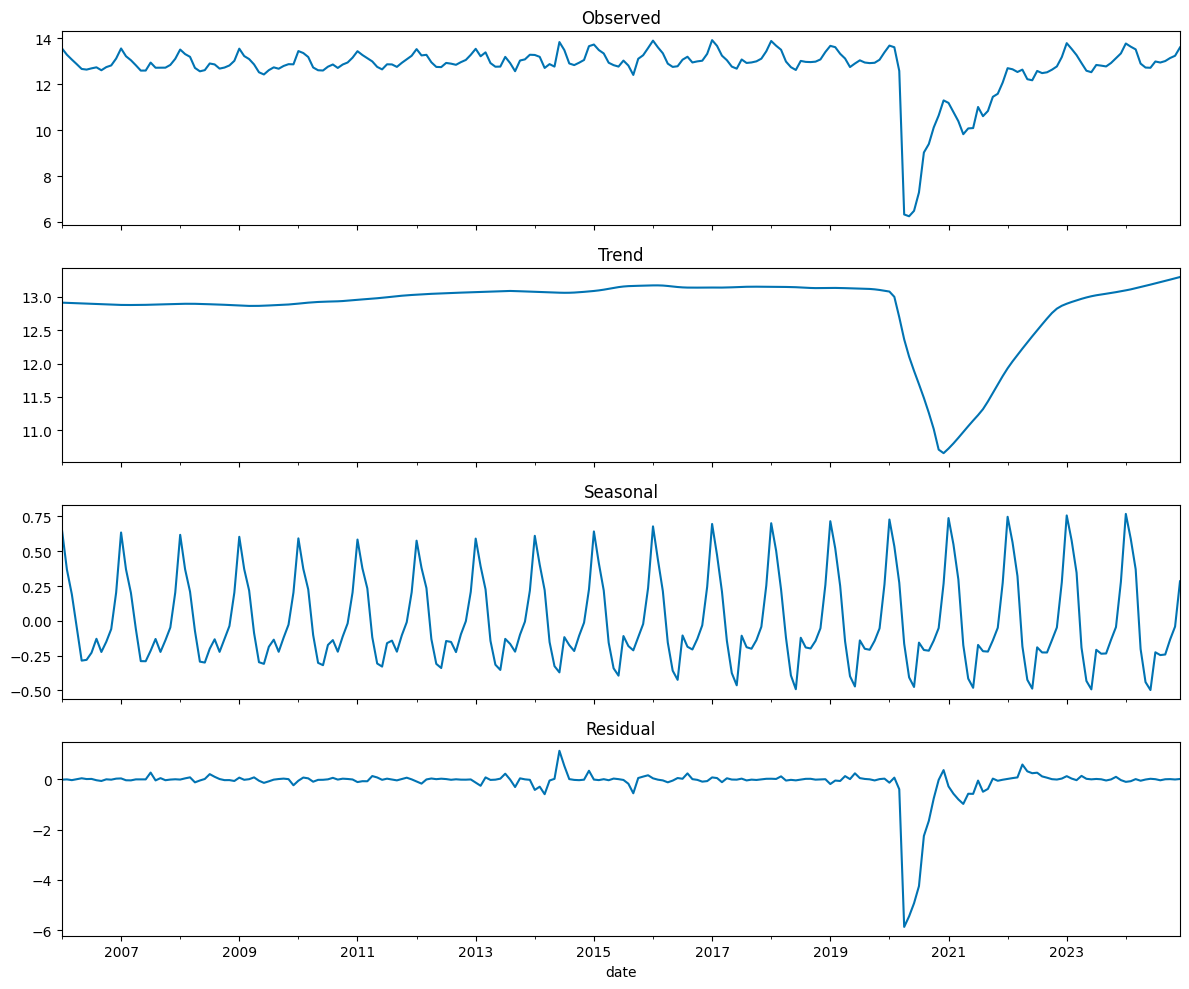

In [19]:
stl = STL(
    np.log(monthly_df['arrival_count'][monthly_df.index.year >= 2006]),
    period=12,
    seasonal=13,
    robust=True,
)
result = stl.fit()

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
result.observed.plot(ax=axes[0], title='Observed')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()